# Pediatric Medical Conditions Visualization

This notebook visualizes the distribution of medical conditions in the Bridge2AI Voice Pediatric Dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
# Load the medical conditions data
df = pd.read_csv('phenotype/pediatric/pediatric_medical_conditions.tsv', sep='\t')

print(f"Total records: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"\nColumn names:")
print(df.columns.tolist())

Total records: 305
Number of columns: 50

Column names:
['participant_id', 'peds_mc_a_therapy', 'peds_mc_adenoidectomy', 'peds_mc_allergies', 'peds_mc_breathing_conditions', 'peds_mc_chronic_medical_condition', 'peds_mc_completed_at', 'peds_mc_conditions', 'peds_mc_dif_swallowing', 'peds_mc_duration', 'peds_mc_ear_inf_ant_py', 'peds_mc_epistaxis', 'peds_mc_etp', 'peds_mc_eval_voice_swal_c', 'peds_mc_fr_inf_tons', 'peds_mc_fr_v_f', 'peds_mc_ft', 'peds_mc_genetic_syndromes', 'peds_mc_hearing_loss', 'peds_mc_hl', 'peds_mc_hospitalized', 'peds_mc_hw_voice_2_w', 'peds_mc_l2w', 'peds_mc_lingual_tonsillectomy', 'peds_mc_meds', 'peds_mc_nasal_fractures', 'peds_mc_neck_mass_branchial_cleft_cyst_surgery', 'peds_mc_neck_mass_dermoid_cyst_surgery', 'peds_mc_neck_mass_enlarged_lymph_node_surgery', 'peds_mc_neck_mass_hyroid_nodule_or_cancer_surgery', 'peds_mc_neck_mass_other', 'peds_mc_neck_mass_thyroglossal_duct_cyst_surgery', 'peds_mc_neurological_disorders', 'peds_mc_neurological_disorders_specif

## Yes/No Condition Prevalence

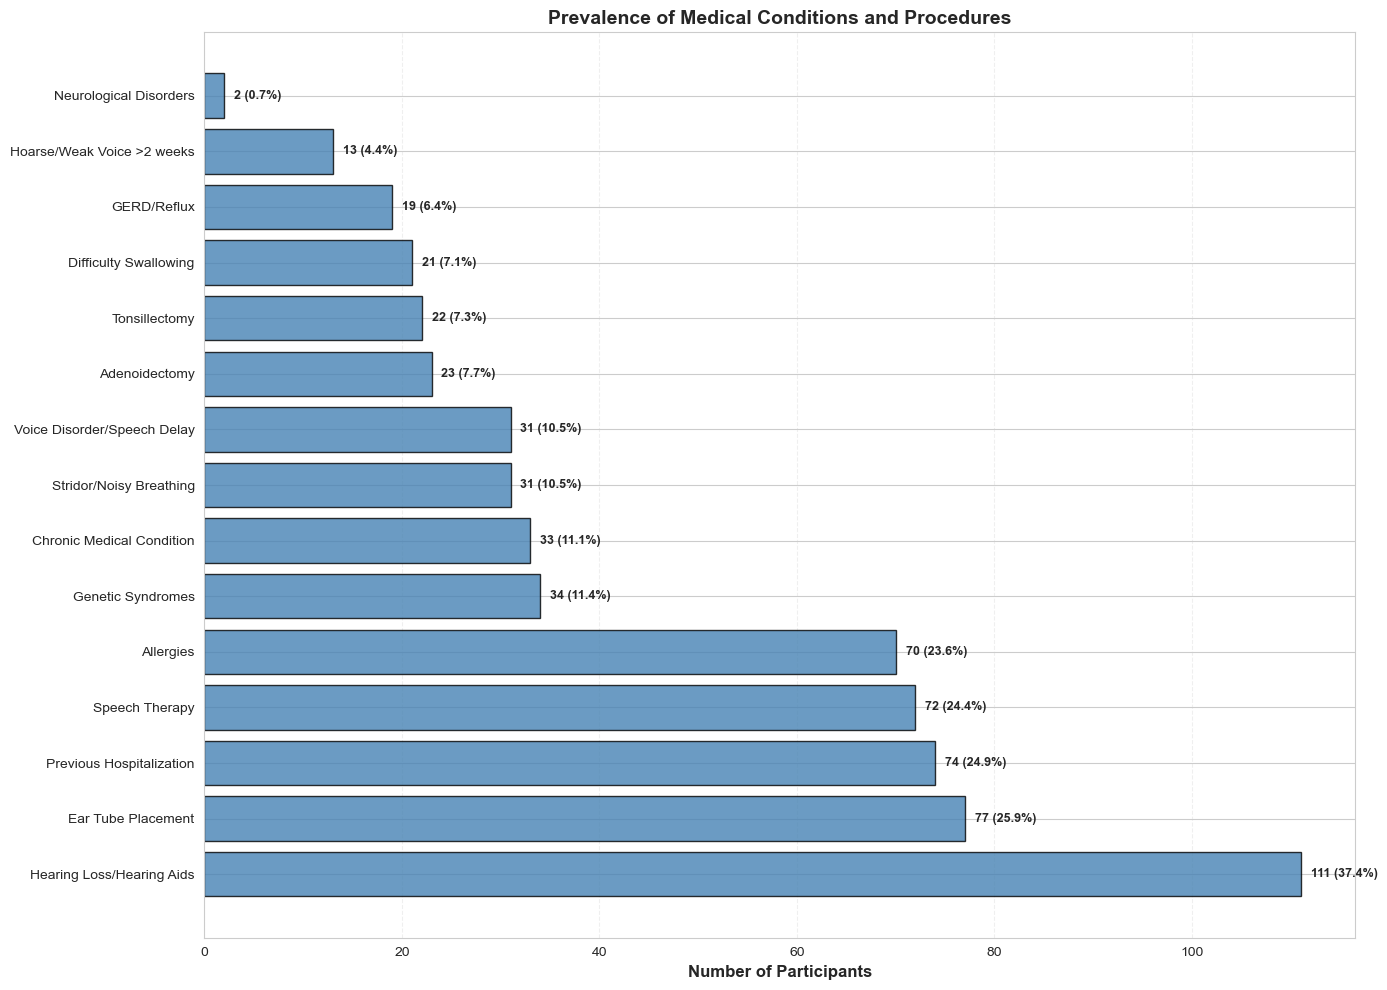

In [3]:
# Key yes/no medical condition columns
yes_no_conditions = {
    'peds_mc_a_therapy': 'Speech Therapy',
    'peds_mc_allergies': 'Allergies',
    'peds_mc_chronic_medical_condition': 'Chronic Medical Condition',
    'peds_mc_dif_swallowing': 'Difficulty Swallowing',
    'peds_mc_hl': 'Hearing Loss/Hearing Aids',
    'peds_mc_hospitalized': 'Previous Hospitalization',
    'peds_mc_hw_voice_2_w': 'Hoarse/Weak Voice >2 weeks',
    'peds_mc_genetic_syndromes': 'Genetic Syndromes',
    'peds_mc_neurological_disorders': 'Neurological Disorders',
    'peds_mc_reflux': 'GERD/Reflux',
    'peds_mc_stridor': 'Stridor/Noisy Breathing',
    'peds_mc_v_dis': 'Voice Disorder/Speech Delay',
    'peds_mc_tonsillectomy': 'Tonsillectomy',
    'peds_mc_adenoidectomy': 'Adenoidectomy',
    'peds_mc_etp': 'Ear Tube Placement',
}

# Calculate percentages
condition_counts = {}
for col, label in yes_no_conditions.items():
    if col in df.columns:
        yes_count = (df[col] == 'Yes').sum()
        total_valid = df[col].notna().sum()
        if total_valid > 0:
            percentage = (yes_count / total_valid) * 100
            condition_counts[label] = {'count': yes_count, 'percentage': percentage}

# Sort by count
sorted_conditions = sorted(condition_counts.items(), key=lambda x: x[1]['count'], reverse=True)

# Create bar plot
plt.figure(figsize=(14, 10))
labels = [item[0] for item in sorted_conditions]
counts = [item[1]['count'] for item in sorted_conditions]
percentages = [item[1]['percentage'] for item in sorted_conditions]

bars = plt.barh(range(len(labels)), counts, color='steelblue', edgecolor='black', alpha=0.8)
plt.yticks(range(len(labels)), labels)
plt.xlabel('Number of Participants', fontsize=12, fontweight='bold')
plt.title('Prevalence of Medical Conditions and Procedures', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
    plt.text(count + 1, bar.get_y() + bar.get_height()/2, 
             f'{int(count)} ({pct:.1f}%)', 
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Hearing Loss Types

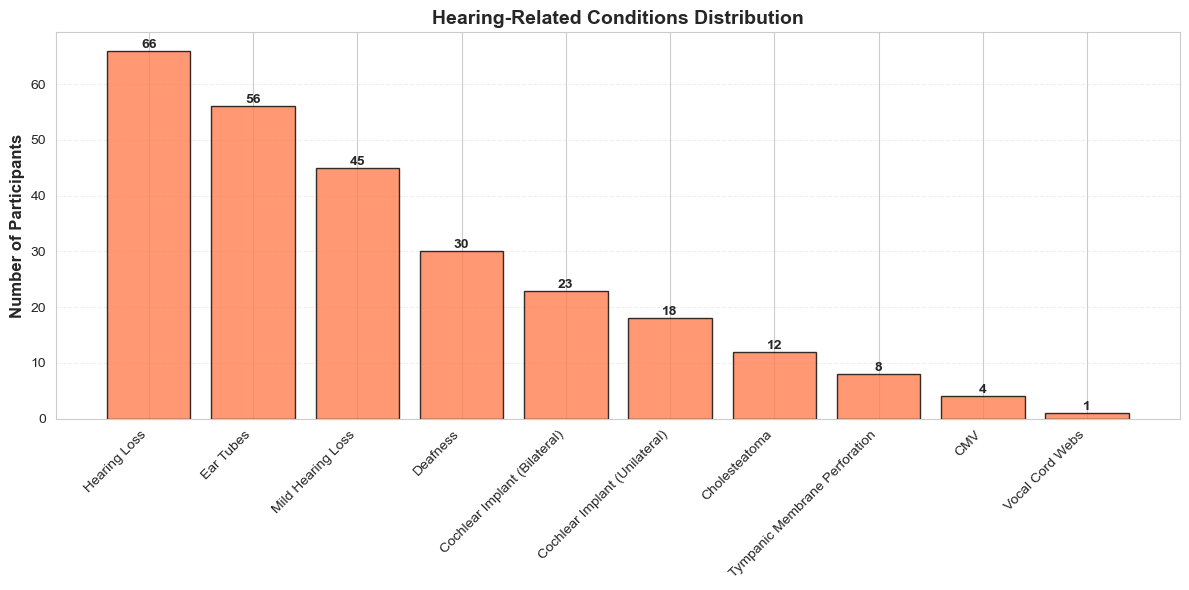

In [4]:
# Parse hearing loss conditions (multi-select field)
hearing_conditions = []
for val in df['peds_mc_hearing_loss'].dropna():
    if isinstance(val, str) and val.strip():
        hearing_conditions.extend([item.strip() for item in val.split(',')])

hearing_counter = Counter(hearing_conditions)

if hearing_counter:
    # Readable labels
    hearing_labels = {
        'hearing loss': 'Hearing Loss',
        'mild hearing loss': 'Mild Hearing Loss',
        'deafness': 'Deafness',
        'cholesteatoma': 'Cholesteatoma',
        'ear tubes': 'Ear Tubes',
        'cochlear implantation bilateral': 'Cochlear Implant (Bilateral)',
        'cochlear implantation unilateral': 'Cochlear Implant (Unilateral)',
        'tympanic membrane perforation': 'Tympanic Membrane Perforation',
        'cmv': 'CMV',
        'vocal cord webs': 'Vocal Cord Webs'
    }
    
    hearing_data = [(hearing_labels.get(k, k.title()), v) for k, v in hearing_counter.most_common()]
    hearing_data = sorted(hearing_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(12, 6))
    labels_h = [item[0] for item in hearing_data]
    counts_h = [item[1] for item in hearing_data]
    
    bars = plt.bar(range(len(labels_h)), counts_h, color='coral', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_h)), labels_h, rotation=45, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Hearing-Related Conditions Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_h):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No hearing loss data found")

## Breathing and Airway Conditions

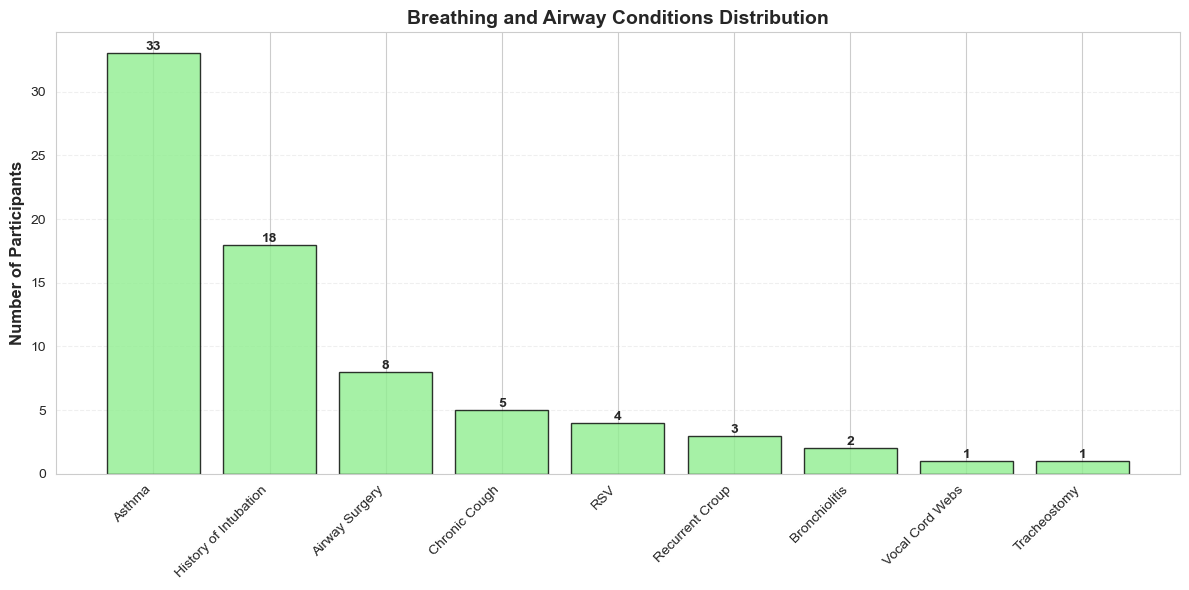

In [5]:
# Parse breathing conditions (multi-select field)
breathing_conditions = []
for val in df['peds_mc_breathing_conditions'].dropna():
    if isinstance(val, str) and val.strip():
        breathing_conditions.extend([item.strip() for item in val.split(',')])

breathing_counter = Counter(breathing_conditions)

if breathing_counter:
    # Readable labels
    breathing_labels = {
        'asthma': 'Asthma',
        'recurrent croup': 'Recurrent Croup',
        'bronchiolitis': 'Bronchiolitis',
        'rsv': 'RSV',
        'chronic cough': 'Chronic Cough',
        'subglottic stenosis': 'Subglottic Stenosis',
        'vocal cord webs': 'Vocal Cord Webs',
        'airway surgery': 'Airway Surgery',
        'intubated': 'History of Intubation',
        'tracheostomy': 'Tracheostomy'
    }
    
    breathing_data = [(breathing_labels.get(k, k.title()), v) for k, v in breathing_counter.most_common()]
    breathing_data = sorted(breathing_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(12, 6))
    labels_b = [item[0] for item in breathing_data]
    counts_b = [item[1] for item in breathing_data]
    
    bars = plt.bar(range(len(labels_b)), counts_b, color='lightgreen', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_b)), labels_b, rotation=45, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Breathing and Airway Conditions Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_b):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No breathing conditions data found")

## Voice Disorders

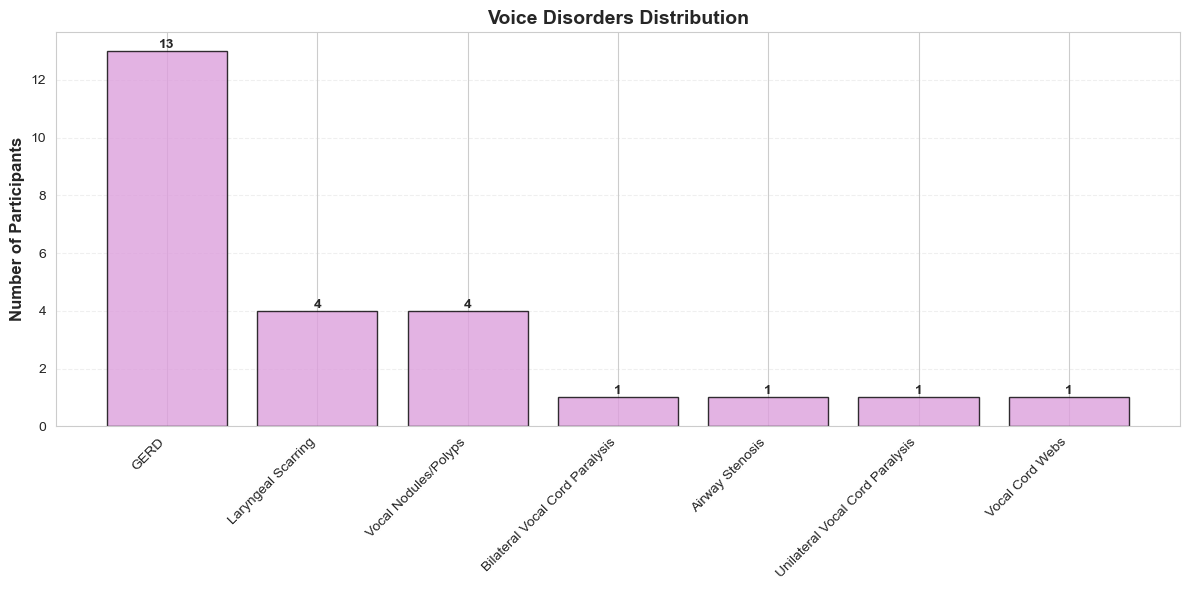

In [6]:
# Parse voice disorders (multi-select field)
voice_disorders = []
for val in df['peds_mc_voice_disorders'].dropna():
    if isinstance(val, str) and val.strip():
        voice_disorders.extend([item.strip() for item in val.split(',')])

voice_counter = Counter(voice_disorders)

if voice_counter:
    # Readable labels
    voice_labels = {
        'vocal nodules or polyps': 'Vocal Nodules/Polyps',
        'unilateral vocal cord paralysis': 'Unilateral Vocal Cord Paralysis',
        'bilateral vocal cord paralysis': 'Bilateral Vocal Cord Paralysis',
        'acid reflux disease': 'GERD',
        'scarring': 'Laryngeal Scarring',
        'airway stenosis': 'Airway Stenosis',
        'vocal cord webs': 'Vocal Cord Webs'
    }
    
    voice_data = [(voice_labels.get(k, k.title()), v) for k, v in voice_counter.most_common()]
    voice_data = sorted(voice_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(12, 6))
    labels_v = [item[0] for item in voice_data]
    counts_v = [item[1] for item in voice_data]
    
    bars = plt.bar(range(len(labels_v)), counts_v, color='plum', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_v)), labels_v, rotation=45, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Voice Disorders Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_v):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No voice disorders data found")

## Sleep-Related Conditions

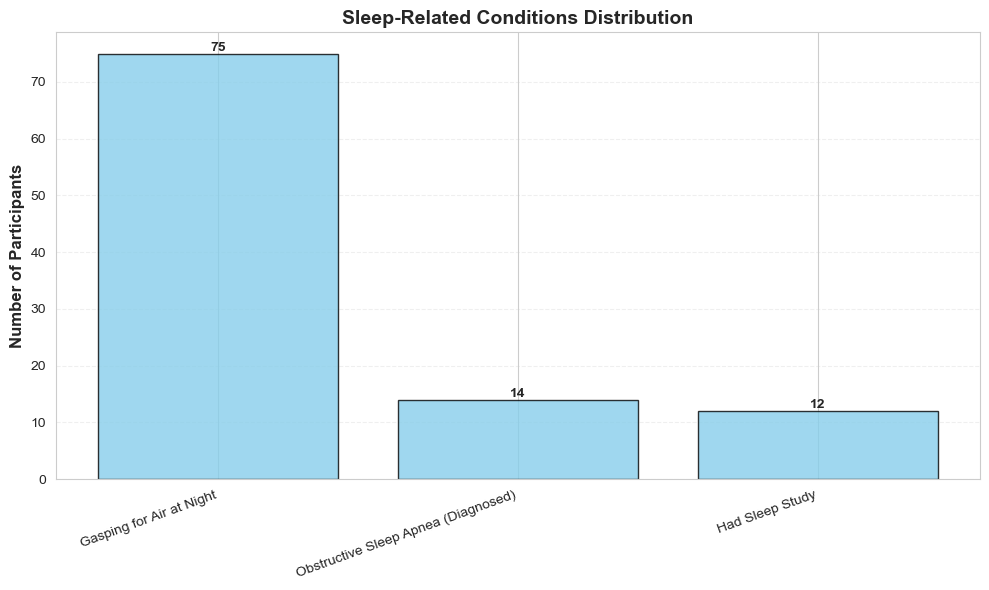

In [7]:
# Parse snoring/apnea conditions (multi-select field)
sleep_conditions = []
for val in df['peds_mc_snoring_apnea'].dropna():
    if isinstance(val, str) and val.strip():
        sleep_conditions.extend([item.strip() for item in val.split(',')])

sleep_counter = Counter(sleep_conditions)

if sleep_counter:
    # Readable labels
    sleep_labels = {
        'snoring': 'Snoring',
        'gasping': 'Gasping for Air at Night',
        'obstructive sleep apnea': 'Obstructive Sleep Apnea (Diagnosed)',
        'had sleep study': 'Had Sleep Study'
    }
    
    sleep_data = [(sleep_labels.get(k, k.title()), v) for k, v in sleep_counter.most_common()]
    sleep_data = sorted(sleep_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(10, 6))
    labels_s = [item[0] for item in sleep_data]
    counts_s = [item[1] for item in sleep_data]
    
    bars = plt.bar(range(len(labels_s)), counts_s, color='skyblue', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_s)), labels_s, rotation=20, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Sleep-Related Conditions Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_s):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No sleep-related data found")

## Recent Symptoms (Last 2 Weeks)

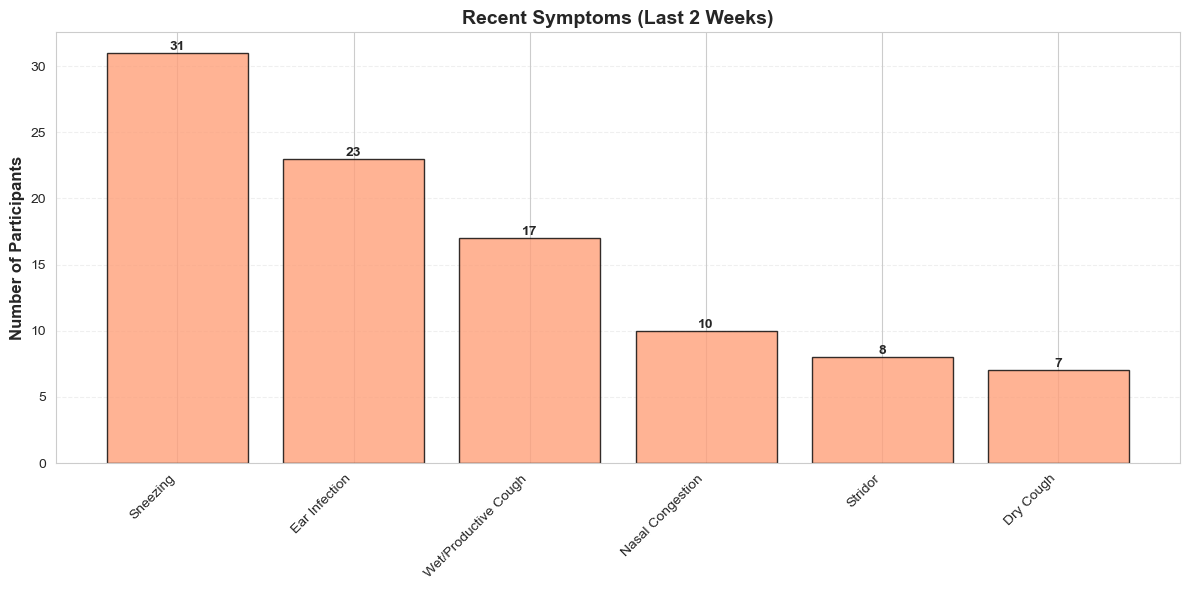

In [8]:
# Parse recent symptoms (multi-select field)
recent_symptoms = []
for val in df['peds_mc_l2w'].dropna():
    if isinstance(val, str) and val.strip():
        recent_symptoms.extend([item.strip() for item in val.split(',')])

recent_counter = Counter(recent_symptoms)

if recent_counter:
    # Readable labels
    recent_labels = {
        'wheezing or trouble breathing': 'Wheezing/Trouble Breathing',
        'dry cough': 'Dry Cough',
        'wet productive cough': 'Wet/Productive Cough',
        'nasal congestion': 'Nasal Congestion',
        'sneezing': 'Sneezing',
        'ear infection': 'Ear Infection',
        'stridor': 'Stridor',
        'croup': 'Croup',
        'sorethroat or tonsillitis': 'Sore Throat/Tonsillitis'
    }
    
    recent_data = [(recent_labels.get(k, k.title()), v) for k, v in recent_counter.most_common()]
    recent_data = sorted(recent_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(12, 6))
    labels_r = [item[0] for item in recent_data]
    counts_r = [item[1] for item in recent_data]
    
    bars = plt.bar(range(len(labels_r)), counts_r, color='lightsalmon', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_r)), labels_r, rotation=45, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Recent Symptoms (Last 2 Weeks)', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_r):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No recent symptoms data found")

## Summary Statistics

In [9]:
print("="*60)
print("MEDICAL CONDITIONS SUMMARY")
print("="*60)
print(f"\nTotal participants with condition data: {df['participant_id'].nunique()}")
print(f"\nTop 5 Most Common Conditions:")
for i, (label, data) in enumerate(sorted_conditions[:5], 1):
    print(f"{i}. {label}: {data['count']} participants ({data['percentage']:.1f}%)")

if hearing_counter:
    print(f"\nMost Common Hearing Condition: {hearing_data[0][0]} ({hearing_data[0][1]} cases)")

if breathing_counter:
    print(f"Most Common Breathing Condition: {breathing_data[0][0]} ({breathing_data[0][1]} cases)")

if voice_counter:
    print(f"Most Common Voice Disorder: {voice_data[0][0]} ({voice_data[0][1]} cases)")

if sleep_counter:
    print(f"Most Common Sleep Symptom: {sleep_data[0][0]} ({sleep_data[0][1]} cases)")

print("\n" + "="*60)

MEDICAL CONDITIONS SUMMARY

Total participants with condition data: 300

Top 5 Most Common Conditions:
1. Hearing Loss/Hearing Aids: 111 participants (37.4%)
2. Ear Tube Placement: 77 participants (25.9%)
3. Previous Hospitalization: 74 participants (24.9%)
4. Speech Therapy: 72 participants (24.4%)
5. Allergies: 70 participants (23.6%)

Most Common Hearing Condition: Hearing Loss (66 cases)
Most Common Breathing Condition: Asthma (33 cases)
Most Common Voice Disorder: GERD (13 cases)
Most Common Sleep Symptom: Gasping for Air at Night (75 cases)



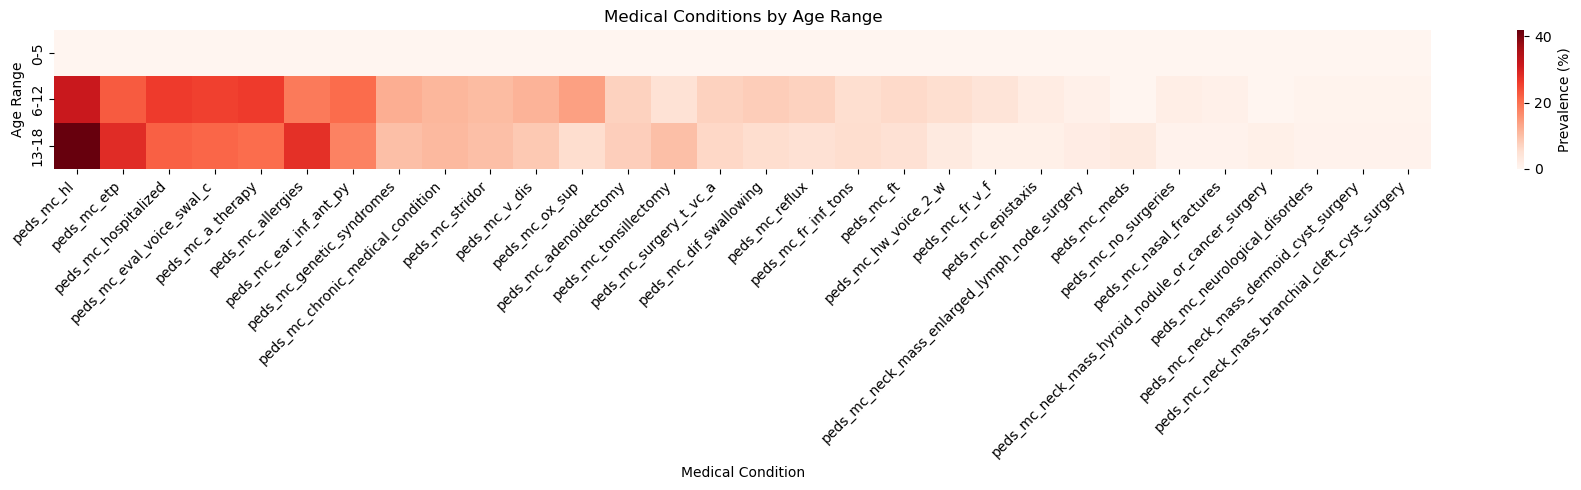

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load files
df_demo = pd.read_csv("phenotype/pediatric/pediatric_demographics.tsv", sep="\t")
df_med = pd.read_csv("phenotype/pediatric/pediatric_medical_conditions.tsv", sep="\t")

# Make IDs consistent
df_demo["participant_id"] = df_demo["participant_id"].astype(str)
df_med["participant_id"] = df_med["participant_id"].astype(str)

# Merge age + medical conditions
df_age_med = df_med.merge(
    df_demo[["participant_id", "age"]],
    on="participant_id",
    how="inner"
)

df_age_med["age"] = pd.to_numeric(df_age_med["age"], errors="coerce")

# Age bins
bins = [0, 5, 12, 18]
labels = ["0-5", "6-12", "13-18"]

df_age_med["age_range"] = pd.cut(
    df_age_med["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Keep only general medical-condition columns
exclude_patterns = [
    "session_id",
    "started_at",
    "completed_at",
    "duration",
    "specified",
    "other",
    "snoring_apnea",   # removes sleep apnea-specific stuff
    "oahi"
]

medical_cols = [
    c for c in df_med.columns
    if c.startswith("peds_mc_")
    and not any(pattern in c for pattern in exclude_patterns)
]

# Convert Yes/No-style medical columns to binary
for col in medical_cols:
    df_age_med[col] = (
        df_age_med[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("yes")
        .astype(int)
    )

# Prevalence by age range
heatmap_data = (
    df_age_med
    .groupby("age_range", observed=True)[medical_cols]
    .mean()
    * 100
)

# Drop all-zero columns and sort by overall prevalence
heatmap_data = heatmap_data.loc[:, heatmap_data.sum(axis=0) > 0]
heatmap_data = heatmap_data[heatmap_data.mean().sort_values(ascending=False).index]

plt.figure(figsize=(18, 5))
sns.heatmap(
    heatmap_data,
    cmap="Reds",
    annot=False,
    cbar_kws={"label": "Prevalence (%)"}
)

plt.title("Medical Conditions by Age Range")
plt.xlabel("Medical Condition")
plt.ylabel("Age Range")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

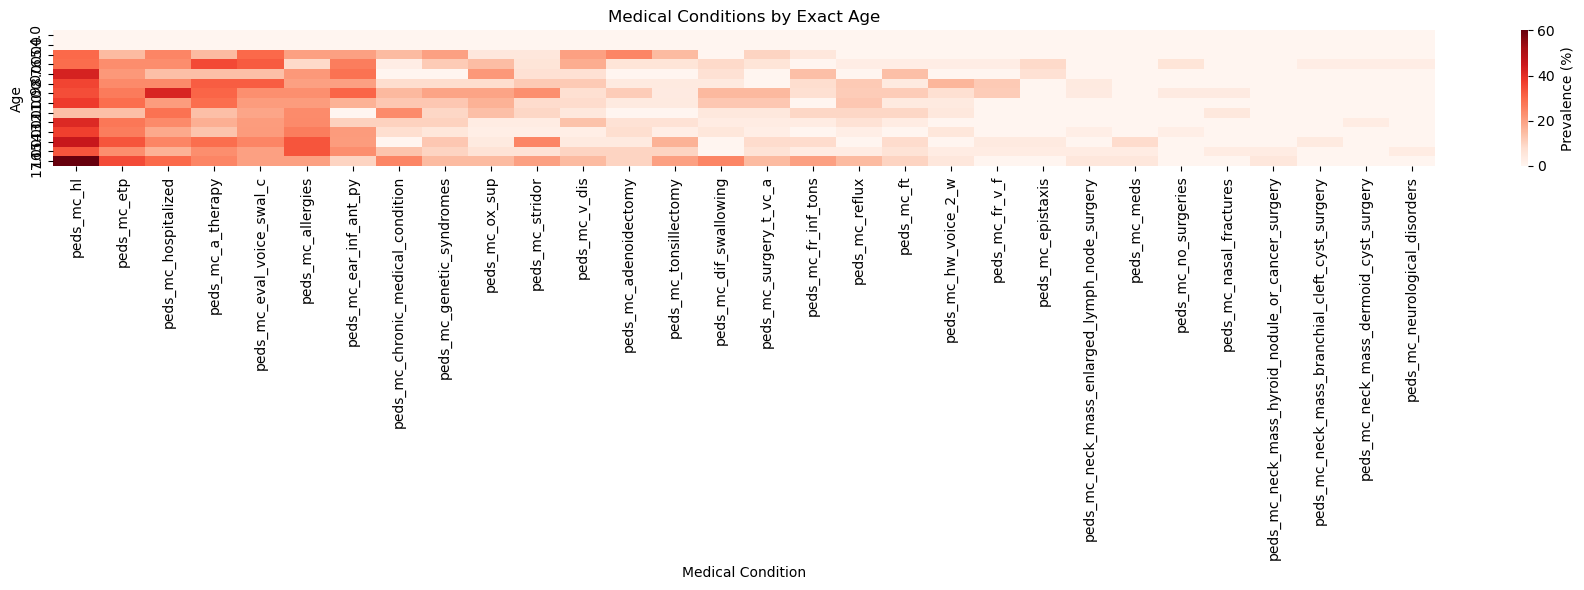

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load
df_demo = pd.read_csv("phenotype/pediatric/pediatric_demographics.tsv", sep="\t")
df_med = pd.read_csv("phenotype/pediatric/pediatric_medical_conditions.tsv", sep="\t")

# Fix types
df_demo["participant_id"] = df_demo["participant_id"].astype(str)
df_med["participant_id"] = df_med["participant_id"].astype(str)

# Merge
df_age_med = df_med.merge(
    df_demo[["participant_id", "age"]],
    on="participant_id",
    how="inner"
)

df_age_med["age"] = pd.to_numeric(df_age_med["age"], errors="coerce")

# -----------------------------
# Select ONLY clean medical columns
# -----------------------------
exclude_patterns = [
    "session_id",
    "started_at",
    "completed_at",
    "duration",
    "specified",
    "other",
    "snoring_apnea",   # remove sleep apnea block
    "oahi"
]

medical_cols = [
    c for c in df_med.columns
    if c.startswith("peds_mc_")
    and not any(p in c for p in exclude_patterns)
]

# Convert Yes/No → binary
for col in medical_cols:
    df_age_med[col] = (
        df_age_med[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("yes")
        .astype(int)
    )

# -----------------------------
# Group by EXACT age
# -----------------------------
heatmap_data = (
    df_age_med
    .dropna(subset=["age"])
    .groupby("age")[medical_cols]
    .mean()
    * 100
)

# Clean columns
heatmap_data = heatmap_data.loc[:, heatmap_data.sum(axis=0) > 0]
heatmap_data = heatmap_data[heatmap_data.mean().sort_values(ascending=False).index]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(18, 6))

sns.heatmap(
    heatmap_data,
    cmap="Reds",
    annot=False,
    cbar_kws={"label": "Prevalence (%)"}
)

plt.title("Medical Conditions by Exact Age")
plt.xlabel("Medical Condition")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

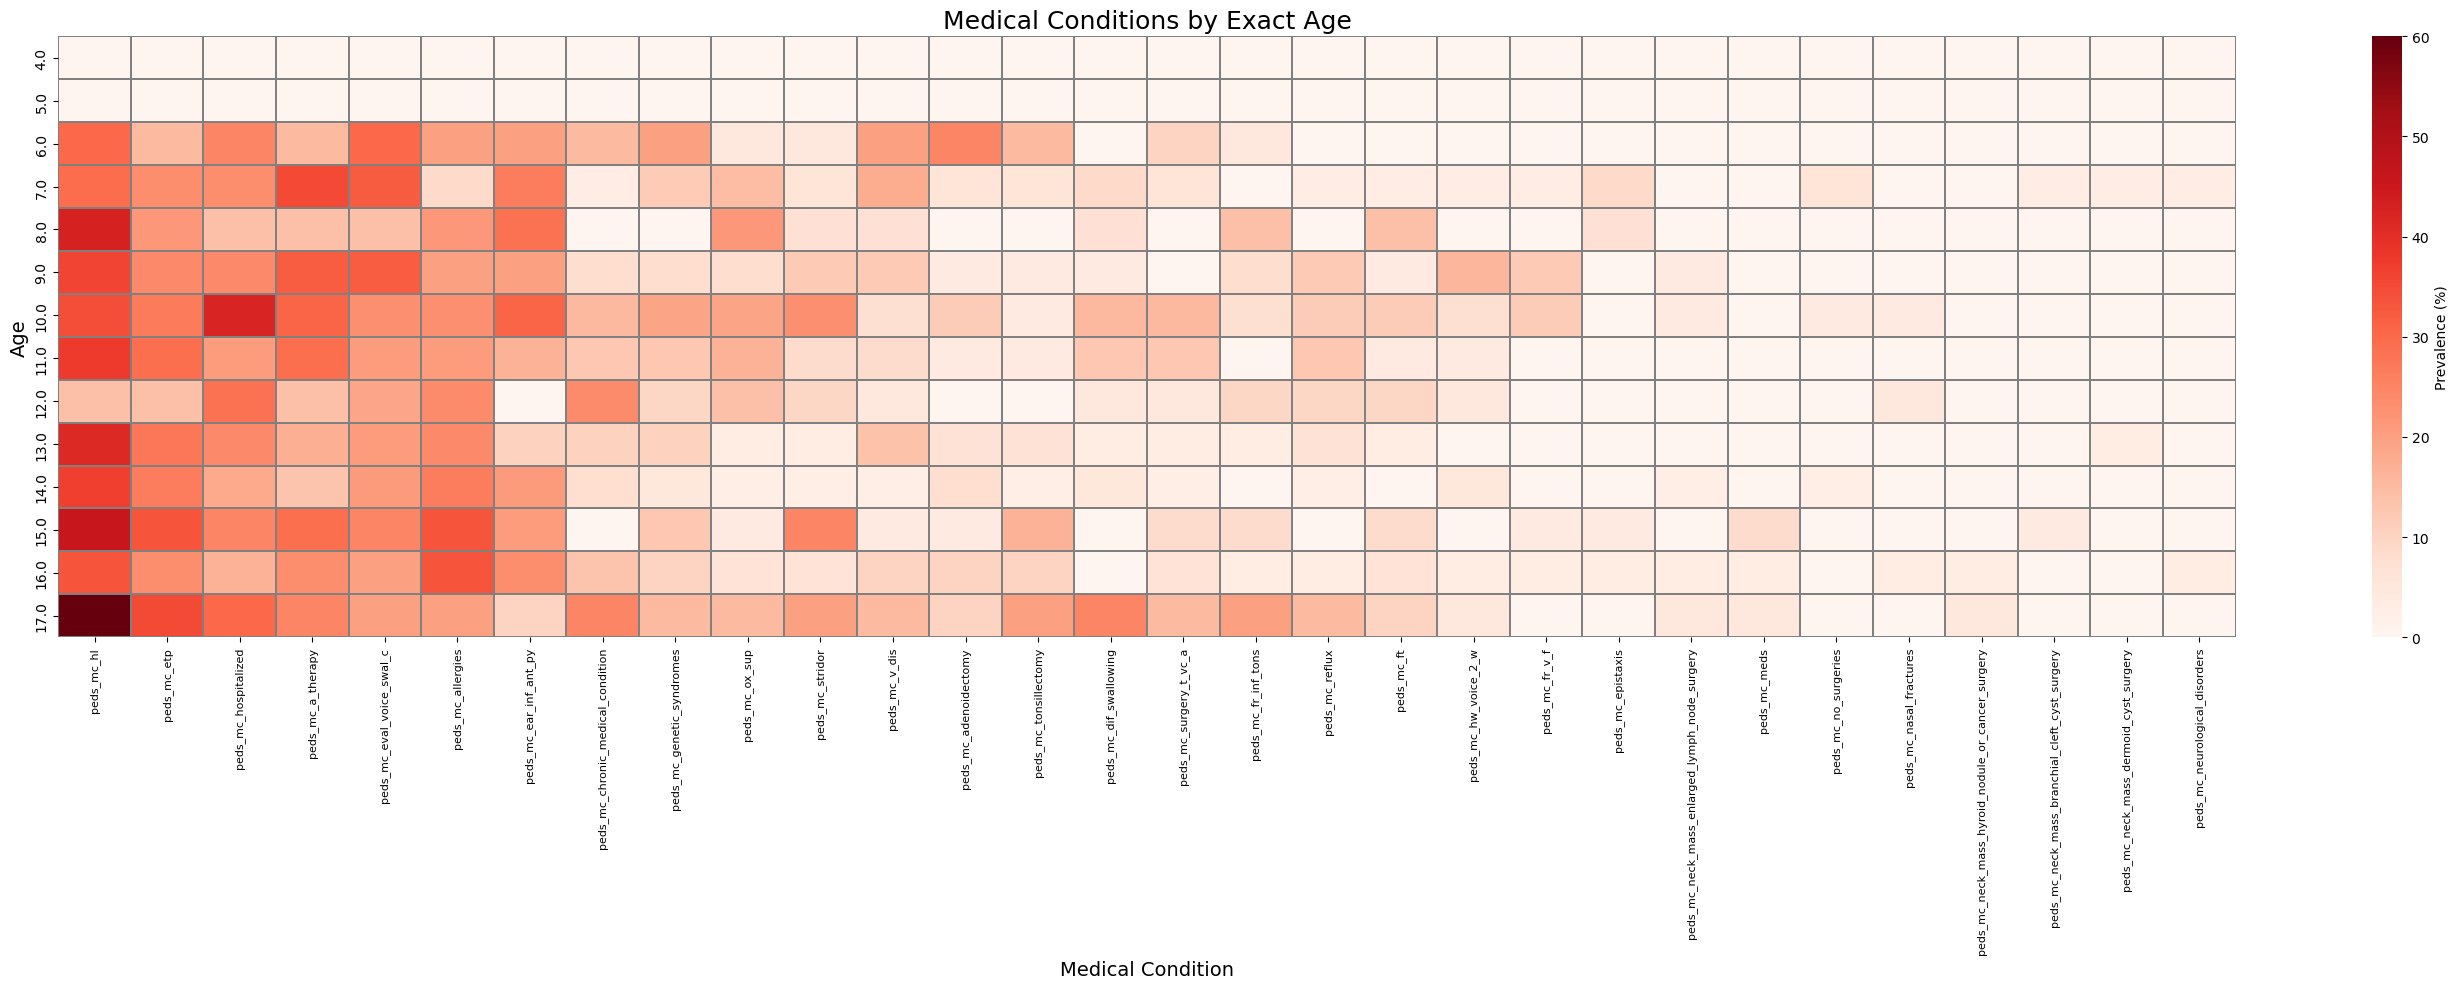

In [11]:
plt.figure(figsize=(28, 10))  # 🔥 increase size

sns.heatmap(
    heatmap_data,
    cmap="Reds",
    annot=False,
    linewidths=0.3,           # subtle grid lines
    linecolor="gray",
    cbar_kws={"label": "Prevalence (%)"}
)

plt.title("Medical Conditions by Exact Age", fontsize=18)
plt.xlabel("Medical Condition", fontsize=14)
plt.ylabel("Age", fontsize=14)

plt.xticks(rotation=90, fontsize=8)   # 🔥 vertical labels (key)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
df_med.columns

Index(['participant_id', 'peds_mc_a_therapy', 'peds_mc_adenoidectomy',
       'peds_mc_allergies', 'peds_mc_breathing_conditions',
       'peds_mc_chronic_medical_condition', 'peds_mc_completed_at',
       'peds_mc_conditions', 'peds_mc_dif_swallowing', 'peds_mc_duration',
       'peds_mc_ear_inf_ant_py', 'peds_mc_epistaxis', 'peds_mc_etp',
       'peds_mc_eval_voice_swal_c', 'peds_mc_fr_inf_tons', 'peds_mc_fr_v_f',
       'peds_mc_ft', 'peds_mc_genetic_syndromes', 'peds_mc_hearing_loss',
       'peds_mc_hl', 'peds_mc_hospitalized', 'peds_mc_hw_voice_2_w',
       'peds_mc_l2w', 'peds_mc_lingual_tonsillectomy', 'peds_mc_meds',
       'peds_mc_nasal_fractures',
       'peds_mc_neck_mass_branchial_cleft_cyst_surgery',
       'peds_mc_neck_mass_dermoid_cyst_surgery',
       'peds_mc_neck_mass_enlarged_lymph_node_surgery',
       'peds_mc_neck_mass_hyroid_nodule_or_cancer_surgery',
       'peds_mc_neck_mass_other',
       'peds_mc_neck_mass_thyroglossal_duct_cyst_surgery',
       'peds_mc_n

In [ ]:
df_med

condition_clean
gasping                             75
hearing loss                        66
ear tubes                           56
mild hearing loss                   45
asthma                              33
sneezing                            31
adhd                                30
deafness                            30
ear infection                       23
cochlear implantation bilateral     23
anxiety disorder                    22
cochlear implantation unilateral    18
intubated                           18
wet productive cough                17
obstructive sleep apnea             14
asd                                 13
acid reflux disease                 13
cholesteatoma                       12
social anxiety disorder             10
nasal congestion                    10
Name: count, dtype: int64

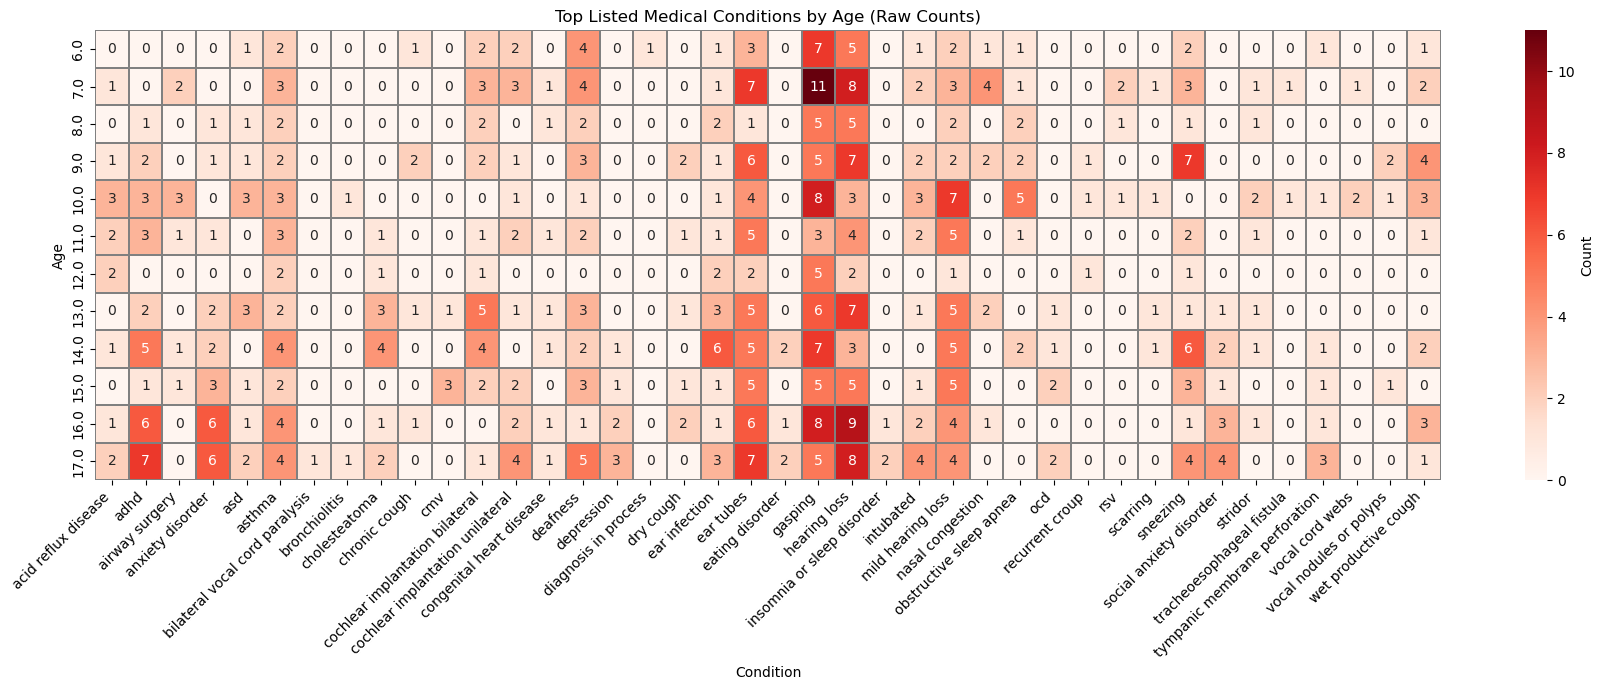

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# -----------------------------
# 1. Text-based condition fields
# -----------------------------
text_cols = [
    # General diagnoses
    "peds_mc_conditions",
    "peds_mc_conditions___other",

    # Neuro / psych
    "peds_mc_neurological_disorders",
    "peds_mc_neurological_disorders_specified",
    "peds_mc_psych_disorders",
    "peds_mc_psych_disorders_other",
    "peds_mc_psych_disorders___other",

    # Respiratory / sleep (VERY important)
    "peds_mc_snoring_apnea",
    "peds_mc_breathing_conditions",

    # Voice / speech related (important for your project)
    "peds_mc_voice_disorders",

    # Hearing (sometimes multi-category)
    "peds_mc_hearing_loss",

    # Less obvious but sometimes categorical
    "peds_mc_l2w",
    "peds_mc_hl"
]

df_text = df_med[["participant_id"] + text_cols].copy()
df_text[text_cols] = df_text[text_cols].fillna("").astype(str)

# Combine all condition text columns into one string
df_text["all_conditions"] = (
    df_text[text_cols]
    .agg(lambda row: ", ".join([x for x in row if x.strip() != ""]), axis=1)
    .str.lower()
)

# -----------------------------
# 2. Split and explode conditions
# -----------------------------
df_text["all_conditions"] = df_text["all_conditions"].str.split(",")

df_exploded = df_text.explode("all_conditions").copy()
df_exploded["all_conditions"] = df_exploded["all_conditions"].astype(str).str.strip()
df_exploded = df_exploded[df_exploded["all_conditions"] != ""]

# -----------------------------
# 3. Clean condition names
# -----------------------------
def clean_condition(text):
    text = text.lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)

    replacements = {
        "cf": "cystic fibrosis",
        "osa": "obstructive sleep apnea",
    }

    for k, v in replacements.items():
        text = text.replace(k, v)

    return text.strip()

df_exploded["condition_clean"] = df_exploded["all_conditions"].apply(clean_condition)
df_exploded = df_exploded[
    ~df_exploded["condition_clean"].isin(["no", "yes", "none", "na", "n a", "nan", ""])
]
# Remove junk / artifacts
junk = ["none", "na", "n a", "nan", "had sleep study", ""]
df_exploded = df_exploded[~df_exploded["condition_clean"].isin(junk)]

# Remove numeric-only artifacts like "10"
df_exploded = df_exploded[
    ~df_exploded["condition_clean"].str.match(r"^\d+$", na=False)
]

# -----------------------------
# 4. Count top conditions
# -----------------------------
condition_counts = df_exploded["condition_clean"].value_counts()
display(condition_counts.head(20))

top_k = 40
top_conditions = condition_counts.head(top_k).index

# -----------------------------
# 5. Merge age
# -----------------------------
df_demo["participant_id"] = df_demo["participant_id"].astype(str)
df_exploded["participant_id"] = df_exploded["participant_id"].astype(str)

df_exploded = df_exploded.merge(
    df_demo[["participant_id", "age"]],
    on="participant_id",
    how="left"
)

df_exploded["age"] = pd.to_numeric(df_exploded["age"], errors="coerce")

# -----------------------------
# 6. Build age x condition count table
# -----------------------------
df_top = df_exploded[df_exploded["condition_clean"].isin(top_conditions)]

heatmap_data = (
    df_top
    .dropna(subset=["age"])
    .groupby(["age", "condition_clean"])
    .size()
    .unstack(fill_value=0)
)

# Sort ages
heatmap_data = heatmap_data.sort_index()

# -----------------------------
# 7. Plot raw count heatmap
# -----------------------------
plt.figure(figsize=(18, 7))

sns.heatmap(
    heatmap_data,
    cmap="Reds",
    annot=True,
    fmt="d",
    linewidths=0.3,
    linecolor="gray",
    cbar_kws={"label": "Count"}
)

plt.title("Top Listed Medical Conditions by Age (Raw Counts)")
plt.xlabel("Condition")
plt.ylabel("Age")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

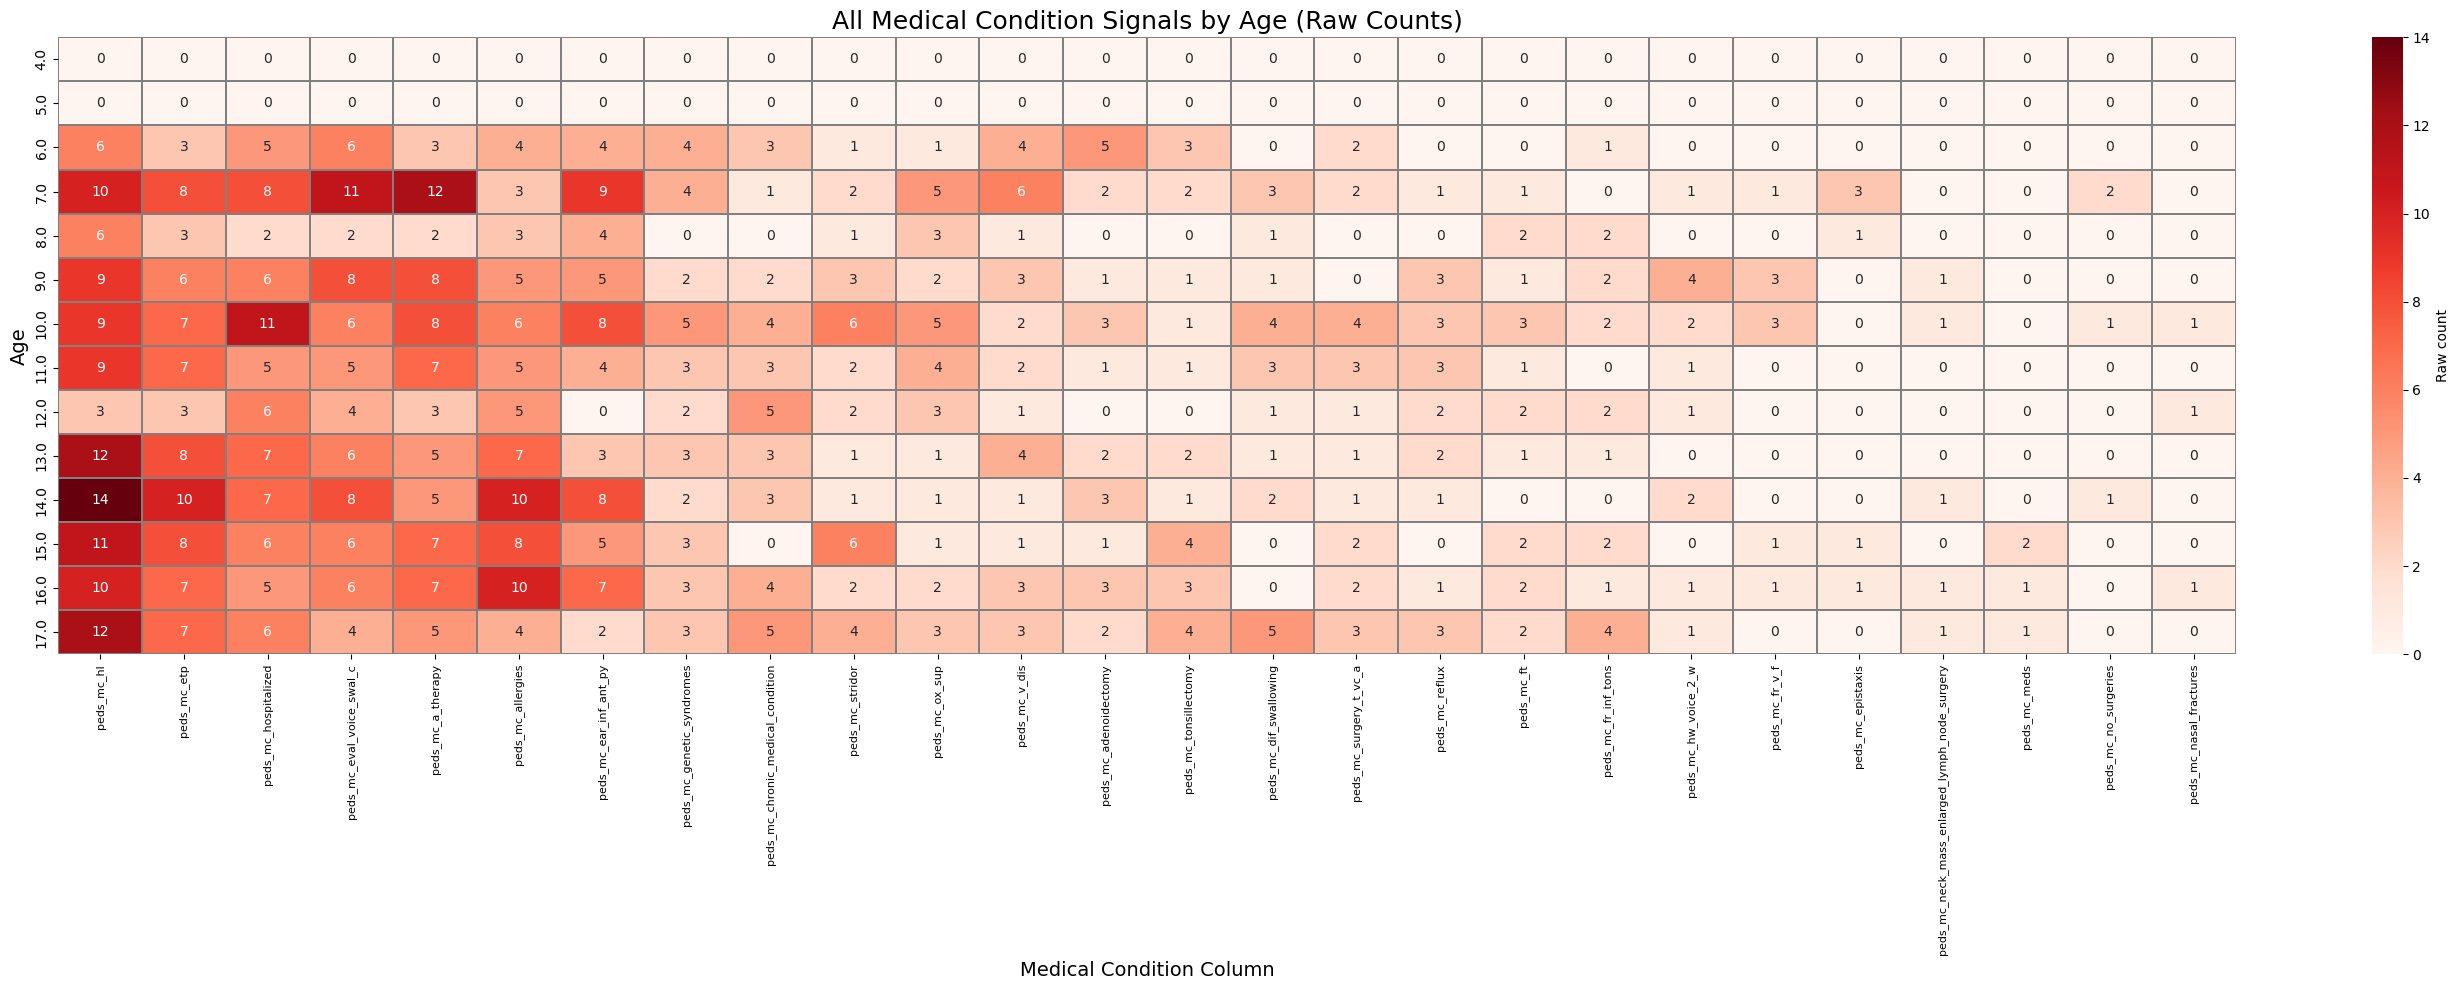

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Start from merged dataset
# -----------------------------
df_full = df_med.merge(
    df_demo[["participant_id", "age"]],
    on="participant_id",
    how="left"
)

df_full["age"] = pd.to_numeric(df_full["age"], errors="coerce")

# -----------------------------
# 2. Select ALL medical columns
# -----------------------------
medical_cols = [c for c in df_med.columns if c.startswith("peds_mc_")]

# Remove ONLY true metadata (keep everything else)
drop_cols = [
    "peds_mc_started_at",
    "peds_mc_completed_at",
    "peds_mc_session_id",
    "peds_mc_duration"
]

medical_cols = [c for c in medical_cols if c not in drop_cols]

# -----------------------------
# 3. Convert Yes/No → binary
# -----------------------------
for col in medical_cols:
    df_full[col] = (
        df_full[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("yes")
        .astype(int)
    )

# -----------------------------
# 4. Build raw count matrix
# -----------------------------
heatmap_counts = (
    df_full
    .dropna(subset=["age"])
    .groupby("age")[medical_cols]
    .sum()
)

# -----------------------------
# 5. Remove completely empty columns
# -----------------------------
heatmap_counts = heatmap_counts.loc[:, heatmap_counts.sum(axis=0) > 0]

# -----------------------------
# 6. OPTIONAL: remove ultra-rare columns (important)
# -----------------------------
min_total = 3   # tweak this
heatmap_counts = heatmap_counts.loc[:, heatmap_counts.sum(axis=0) >= min_total]

# -----------------------------
# 7. Sort columns by total count
# -----------------------------
heatmap_counts = heatmap_counts[
    heatmap_counts.sum().sort_values(ascending=False).index
]

# -----------------------------
# 8. Plot
# -----------------------------
plt.figure(figsize=(28, 10))

sns.heatmap(
    heatmap_counts,
    cmap="Reds",
    annot=True,
    fmt=".0f",
    linewidths=0.3,
    linecolor="gray",
    cbar_kws={"label": "Raw count"}
)

plt.title("All Medical Condition Signals by Age (Raw Counts)", fontsize=18)
plt.xlabel("Medical Condition Column", fontsize=14)
plt.ylabel("Age", fontsize=14)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [25]:
import pandas as pd

# -----------------------------
# 1. TEXT-based condition fields
# -----------------------------
text_cols = [
    "peds_mc_conditions",
    "peds_mc_conditions___other",
    "peds_mc_neurological_disorders_specified",
    "peds_mc_psych_disorders_other",
    "peds_mc_psych_disorders___other"
]

df_text = df_med[["participant_id"] + text_cols].copy()

df_text["conditions"] = (
    df_text[text_cols]
    .fillna("")
    .astype(str)
    .agg(", ".join, axis=1)
    .str.lower()
    .str.split(",")
)

df_text = df_text.explode("conditions")
df_text["conditions"] = df_text["conditions"].str.strip()
df_text = df_text[df_text["conditions"] != ""]


# -----------------------------
# 2. MULTI-SELECT columns (CRITICAL FIX)
# -----------------------------
multi_cols = [
    "peds_mc_hearing_loss",
    "peds_mc_breathing_conditions",
    "peds_mc_psych_disorders",
    "peds_mc_voice_disorders",
    "peds_mc_l2w",
    "peds_mc_snoring_apnea"
]

df_multi = df_med[["participant_id"] + multi_cols].copy()

df_multi["conditions"] = (
    df_multi[multi_cols]
    .fillna("")
    .astype(str)
    .agg(", ".join, axis=1)
    .str.lower()
    .str.split(",")
)

df_multi = df_multi.explode("conditions")
df_multi["conditions"] = df_multi["conditions"].str.strip()
df_multi = df_multi[df_multi["conditions"] != ""]


# -----------------------------
# 3. COMBINE EVERYTHING
# -----------------------------
df_all = pd.concat([df_text[["participant_id", "conditions"]],
                    df_multi[["participant_id", "conditions"]]])

# Clean
df_all["conditions"] = df_all["conditions"].str.replace("_", " ")
df_all["conditions"] = df_all["conditions"].str.strip()

# -----------------------------
# 4. MERGE AGE
# -----------------------------
df_all = df_all.merge(df_demo[["participant_id", "age"]], on="participant_id")

df_all = df_all.dropna(subset=["age"])
df_all["age"] = df_all["age"].astype(int)


# -----------------------------
# 5. CREATE HEATMAP DATA (RAW COUNTS)
# -----------------------------
heatmap_data = (
    df_all
    .groupby(["age", "conditions"])
    .size()
    .unstack(fill_value=0)
)


# -----------------------------
# 6. FILTER TOP CONDITIONS (optional but recommended)
# -----------------------------
top_conditions = df_all["conditions"].value_counts().head(30).index
heatmap_data = heatmap_data[top_conditions]

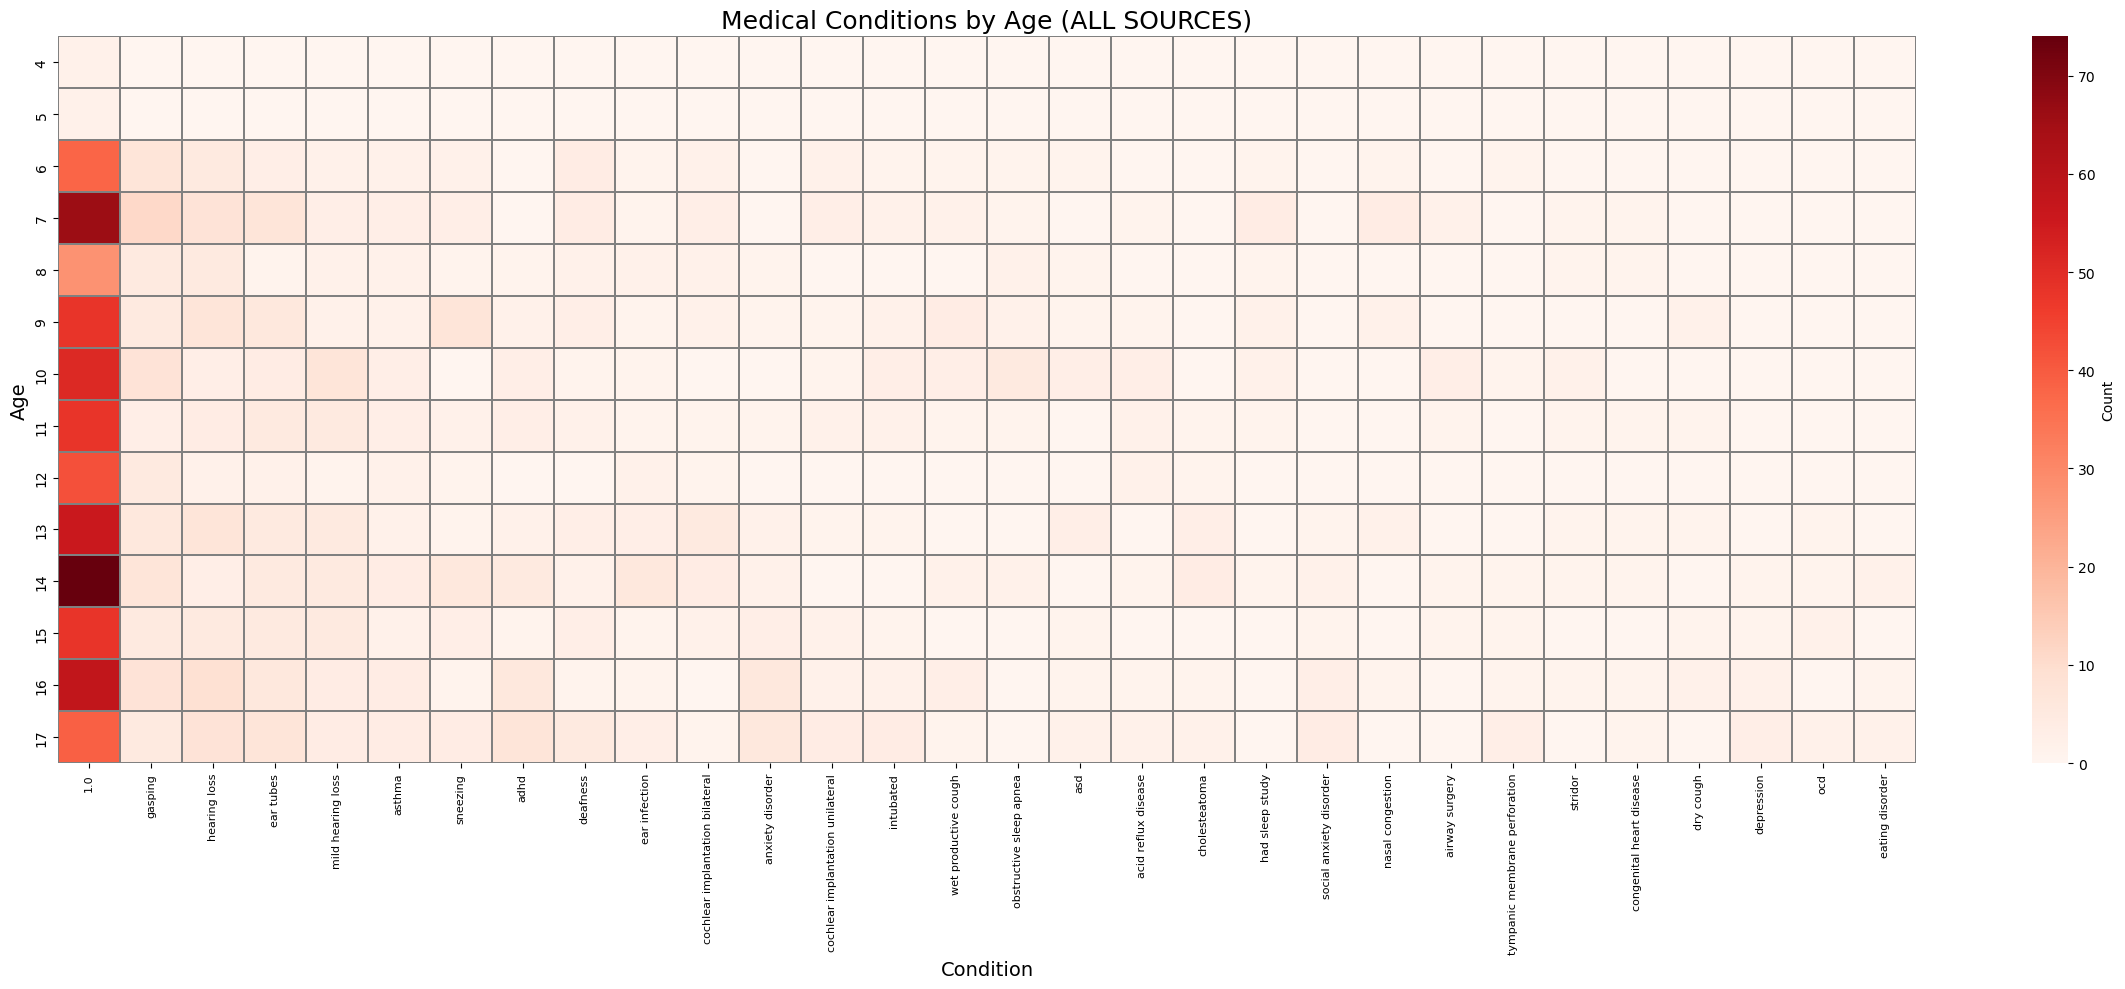

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 10))

sns.heatmap(
    heatmap_data,
    cmap="Reds",
    annot=False,
    linewidths=0.3,
    linecolor="gray",
    cbar_kws={"label": "Count"}
)

plt.title("Medical Conditions by Age (ALL SOURCES)", fontsize=18)
plt.xlabel("Condition", fontsize=14)
plt.ylabel("Age", fontsize=14)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

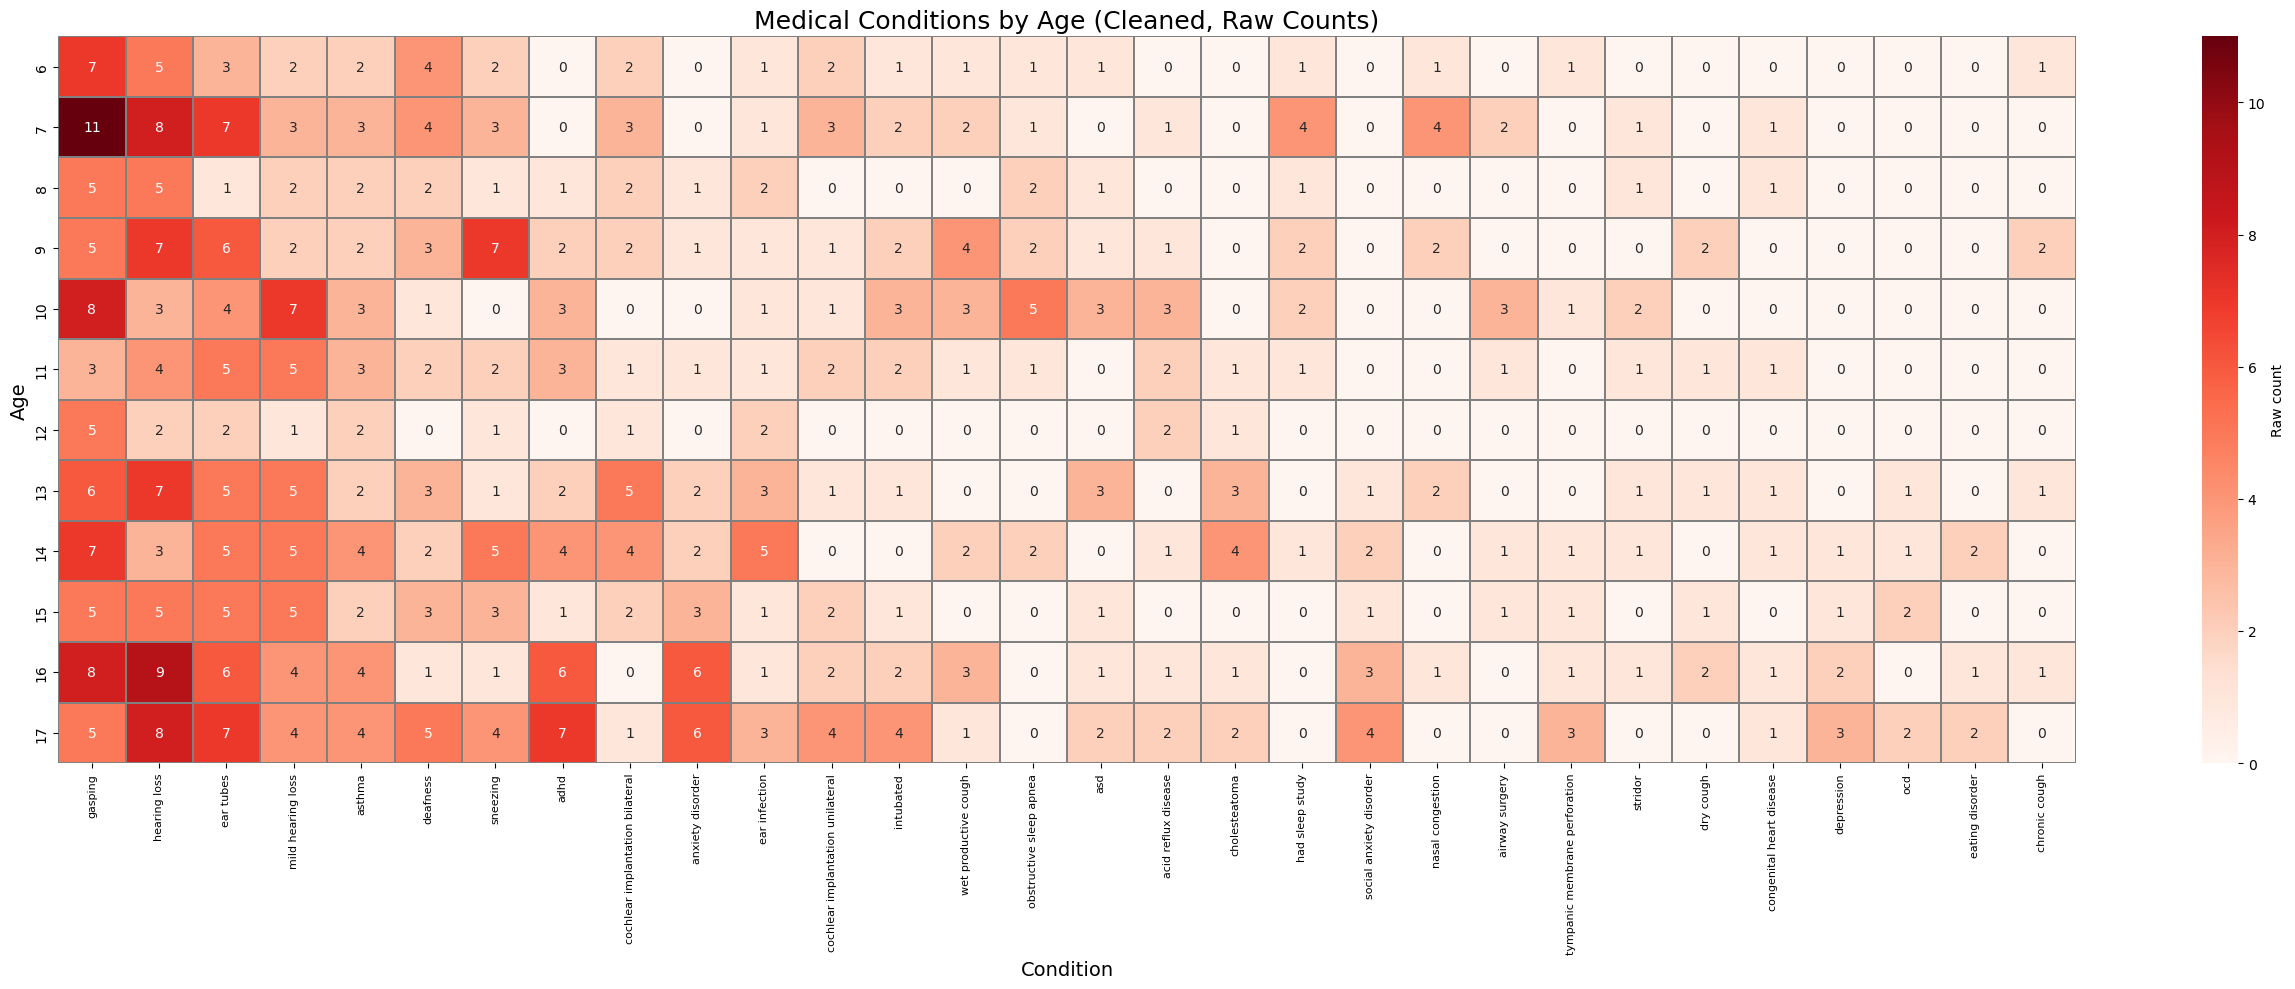

condition
gasping                             75
hearing loss                        66
ear tubes                           56
mild hearing loss                   45
asthma                              33
deafness                            30
sneezing                            30
adhd                                29
cochlear implantation bilateral     23
anxiety disorder                    22
ear infection                       22
cochlear implantation unilateral    18
intubated                           18
wet productive cough                17
obstructive sleep apnea             14
asd                                 13
acid reflux disease                 13
cholesteatoma                       12
had sleep study                     12
social anxiety disorder             11
nasal congestion                    10
airway surgery                       8
tympanic membrane perforation        8
stridor                              8
dry cough                            7
congenital hear

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# -----------------------------
# 1. Define columns correctly
# -----------------------------

# Real multi-select condition columns
multi_cols = [
    "peds_mc_hearing_loss",
    "peds_mc_breathing_conditions",
    "peds_mc_psych_disorders",
    "peds_mc_voice_disorders",
    "peds_mc_l2w",
    "peds_mc_snoring_apnea",
]

# Real free-text / diagnosis fields
text_cols = [
    "peds_mc_conditions",
    "peds_mc_neurological_disorders_specified",
    "peds_mc_psych_disorders_other",
    "peds_mc_neck_mass_other",
]

# Do NOT include:
# peds_mc_conditions___other
# peds_mc_psych_disorders___other
# because these are checkbox indicator fields, not condition names.

# -----------------------------
# 2. Helper function
# -----------------------------
def clean_condition(x):
    x = str(x).lower().strip()
    x = x.replace("_", " ")
    x = re.sub(r"[^\w\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

# -----------------------------
# 3. Explode multi-select + text fields
# -----------------------------
rows = []

for _, row in df_med.iterrows():
    pid = str(row["participant_id"])

    for col in multi_cols + text_cols:
        val = row.get(col)

        if pd.isna(val):
            continue

        val = str(val).lower().strip()

        # split multi-select strings
        parts = re.split(r",|;|\|", val)

        for part in parts:
            cond = clean_condition(part)

            # remove junk artifacts
            if cond in ["", "nan", "none", "no", "yes", "0", "0 0", "1", "1 0", "1 0 0"]:
                continue

            # remove numeric-only artifacts like "1.0"
            if re.match(r"^\d+(\.\d+)?$", cond):
                continue

            rows.append({
                "participant_id": pid,
                "condition": cond
            })

df_conditions = pd.DataFrame(rows)

# -----------------------------
# 4. Deduplicate participant-condition pairs
# -----------------------------
df_conditions = df_conditions.drop_duplicates(["participant_id", "condition"])

# -----------------------------
# 5. Merge age
# -----------------------------
df_demo["participant_id"] = df_demo["participant_id"].astype(str)

df_conditions = df_conditions.merge(
    df_demo[["participant_id", "age"]],
    on="participant_id",
    how="left"
)

df_conditions["age"] = pd.to_numeric(df_conditions["age"], errors="coerce")
df_conditions = df_conditions.dropna(subset=["age"])
df_conditions["age"] = df_conditions["age"].astype(int)

# -----------------------------
# 6. Raw count heatmap
# -----------------------------
top_k = 30
top_conditions = df_conditions["condition"].value_counts().head(top_k).index

heatmap_data = (
    df_conditions[df_conditions["condition"].isin(top_conditions)]
    .groupby(["age", "condition"])
    .size()
    .unstack(fill_value=0)
)

heatmap_data = heatmap_data[top_conditions]

# -----------------------------
# 7. Plot
# -----------------------------
plt.figure(figsize=(26, 10))

sns.heatmap(
    heatmap_data,
    cmap="Reds",
    annot=True,
    fmt="d",
    linewidths=0.3,
    linecolor="gray",
    cbar_kws={"label": "Raw count"}
)

plt.title("Medical Conditions by Age (Cleaned, Raw Counts)", fontsize=18)
plt.xlabel("Condition", fontsize=14)
plt.ylabel("Age", fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

# Check top counts
df_conditions["condition"].value_counts().head(30)

In [28]:
df_conditions["participant_id"].nunique()

221